# Peak-to-gene linkage (multiome)

A scATAC peak is only useful once you know *which gene it regulates*. With paired RNA + ATAC
(10x multiome) we can learn those links directly: for each peak–gene pair within a genomic
window, correlate peak accessibility against gene expression across **metacells**, and keep the
significant correlations. This is the ArchR / `addPeak2GeneLinks` idea, exposed in `ov.epi` as
`ov.epi.tl.peak_to_gene`.

This tutorial uses the public **10x PBMC 10k multiome** dataset (paired scRNA + scATAC, GRCh38),
which `ov.epi.datasets` downloads on demand:

1. load the paired ATAC peak matrix + RNA matrix
2. build an ATAC embedding with iterative LSI
3. correlate peaks with genes (`ov.epi.tl.peak_to_gene`)
4. visualise the links around marker genes with `ov.epi.pl.plot_peak2gene`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import omicverse as ov
ov.epi.pl.plot_set()
print('omicverse', ov.__version__)

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

omicverse 2.2.1rc1


## 1 · Load the paired multiome data

`ov.epi.datasets.pbmc10k_multiome()` returns two AnnData objects sharing the same cell barcodes —
an ATAC **peak** matrix and an RNA count matrix, both already annotated with `cell_type`.

In [2]:
atac, rna = ov.epi.datasets.pbmc10k_multiome()
print('ATAC:', atac.shape, '| RNA:', rna.shape)
print('paired barcodes:', bool((atac.obs_names == rna.obs_names).all()))
atac.obs['cell_type'].value_counts().head()

ATAC: (9631, 107194) | RNA: (9631, 29095)
paired barcodes: True


cell_type
CD14 Mono    2554
CD4 Naive    1382
CD8 Naive    1354
CD4 TCM      1113
CD16 Mono     442
Name: count, dtype: int64

## 2 · Gene and exon annotation

Both `peak_to_gene` (to find each gene's TSS) and the linkage plot (to draw the gene model) need
a gene/exon annotation table. We read it from the bundled GRCh38 Gencode GFF3 with pyranges.

In [3]:
import pyranges as pr

gtf_path = ov.epi.data.hg38.annotation
g = pr.read_gff3(str(gtf_path)).df

def _ann(feature):
    sub = g[g.Feature == feature]
    return pd.DataFrame({
        'gene_name': sub['gene_name'].astype(str).values,
        'chrom':     sub['Chromosome'].astype(str).values,
        'start':     sub['Start'].astype(int).values,
        'end':       sub['End'].astype(int).values,
        'strand':    sub['Strand'].astype(str).values,
    })

gene_ann = _ann('gene')
exon_ann = _ann('exon')
print('genes:', len(gene_ann), '| exons:', len(exon_ann))

genes: 61852 | exons: 839796


## 3 · ATAC embedding

`peak_to_gene` groups cells into metacells using a low-dimensional embedding; we compute the
standard ArchR-style iterative LSI on the ATAC peaks.

In [4]:
ov.epi.tl.iterative_lsi(atac, n_components=30, iterations=2, var_features=25000,
                        resolution=0.5, n_neighbors=30, seed=1)
print('ATAC embedding:', atac.obsm['X_iterative_lsi'].shape)

  └─ [iterative_lsi] Initial feature set: 106,658 / 107,194


  └─ [iterative_lsi] Iter 1/2 | fit on 9,631 cells x 106,658 features


computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:32)


running Leiden clustering


    finished: found 14 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


  └─ [iterative_lsi]   -> 14 clusters; selected 25,000 variable features for next round


  └─ [iterative_lsi] Iter 2/2 | fit on 9,631 cells x 25,000 features


  └─ [iterative_lsi] Done. Stored embedding (9,631 x 29) in adata.obsm['X_iterative_lsi']
ATAC embedding: (9631, 29)


## 4 · Correlate peaks with genes

`ov.epi.tl.peak_to_gene` aggregates cells into metacells, then correlates each peak with every
gene whose TSS lies within `max_distance` (250 kb) of the peak, returning a tidy table of links
with a correlation, p-value and FDR.

In [5]:
links = ov.epi.tl.peak_to_gene(
    atac, rna=rna, gene_annotation=gene_ann,
    use_rep='X_iterative_lsi',
    n_metacells=500, k_neighbors=100, max_distance=250_000, seed=1,
)
sig = links[links['fdr'] < 0.05]
print(f'{len(links):,} peak-gene pairs | {len(sig):,} significant (FDR < 0.05)')
links.head()

  └─ [peak_to_gene] 107,194 peaks | 20,169 annotated genes | 9,631 cells
  └─ [peak_to_gene] Building 500 metacells × 100 neighbours from X_iterative_lsi
  └─ [peak_to_gene] Aggregating peak matrix


  └─ [peak_to_gene] Aggregating gene matrix


  └─ [peak_to_gene] Finding peak-gene pairs within ±250,000 bp


  └─ [peak_to_gene] 726,292 candidate pairs
  └─ [peak_to_gene] Computing correlations


  └─ [peak_to_gene] 726,292 pairs retained, 441,342 significant (FDR < 0.05)
726,292 peak-gene pairs | 441,342 significant (FDR < 0.05)


,peak,gene,chrom,peak_start,peak_end,gene_start,gene_end,tss,distance,correlation,t,p_value,fdr
0,chr1:816881-817647,LINC01409,chr1,816881,817647,778746,810065,778746,38518,0.367556,8.819705,1.937570e-17,1.153987e-16
1,chr1:816881-817647,FAM87B,chr1,816881,817647,817370,819837,817370,-106,0.214858,4.909412,1.240268e-06,3.701546e-06
2,chr1:816881-817647,LINC01128,chr1,816881,817647,825137,859446,825137,-7873,0.103890,2.331009,2.015113e-02,3.446575e-02
3,chr1:816881-817647,LINC00115,chr1,816881,817647,824227,827539,827539,-10275,0.546485,14.562097,2.831169e-40,3.955713e-39
4,chr1:816881-817647,FAM41C,chr1,816881,817647,868070,876903,876903,-59639,0.165115,3.735962,2.086407e-04,4.896519e-04


### Properties of the significant links

Two quick diagnostics: significant links are enriched at short peak–TSS distances, and positive
correlations dominate (accessible enhancers tend to *raise* expression).

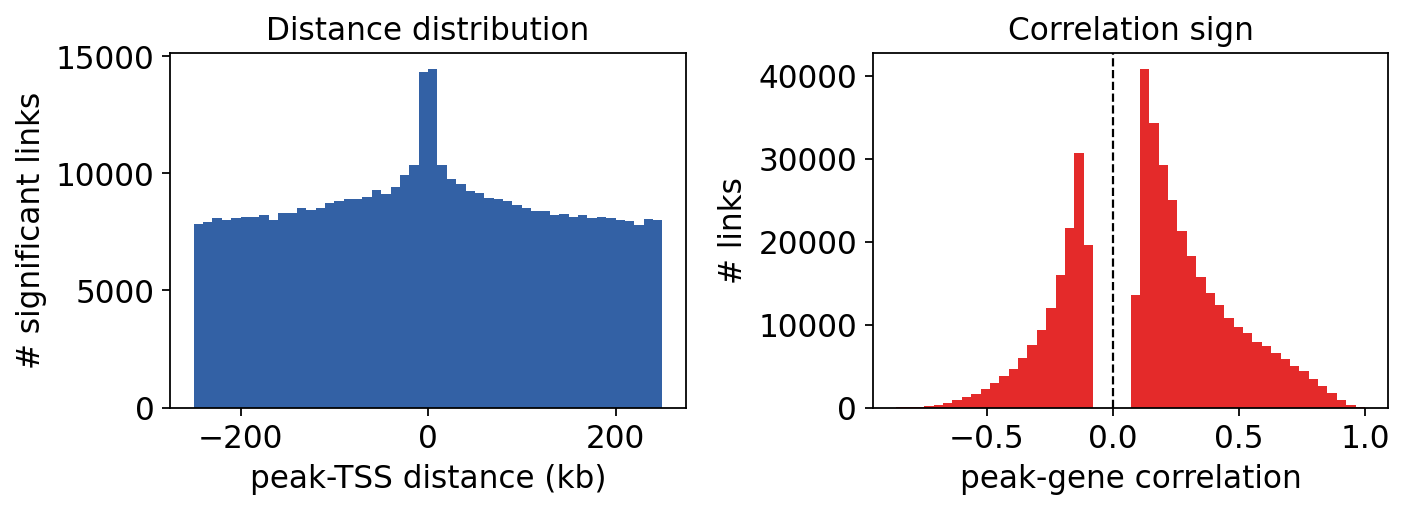

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].hist(sig['distance'] / 1000, bins=50, color='#3361A5')
axes[0].set_xlabel('peak-TSS distance (kb)'); axes[0].set_ylabel('# significant links')
axes[0].set_title('Distance distribution')

axes[1].hist(sig['correlation'], bins=50, color='#E42A2A')
axes[1].axvline(0, color='k', lw=1, ls='--')
axes[1].set_xlabel('peak-gene correlation'); axes[1].set_ylabel('# links')
axes[1].set_title('Correlation sign')
plt.tight_layout(); plt.show()

## 5 · Visualise links around marker genes

`ov.epi.pl.plot_peak2gene` draws a genome-browser-style panel: the gene model, the peaks, and
arcs connecting each peak to the gene coloured by correlation. **CD3D** is a pan-T-cell gene.

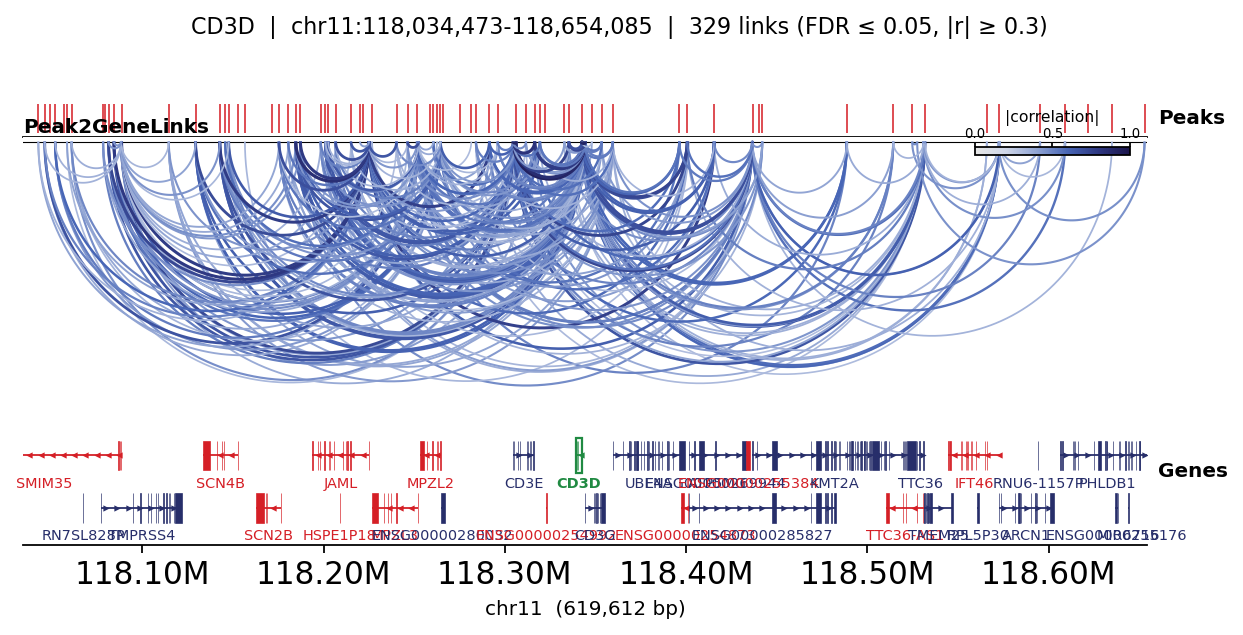

In [7]:
fig, _ = ov.epi.pl.plot_peak2gene(
    atac, gene='CD3D',
    gene_annotation=gene_ann, exon_annotation=exon_ann,
    fdr_thresh=0.05, min_abs_r=0.3, pad_bp=80_000, figsize=(8, 4), show=False,
)
plt.tight_layout(); plt.show()

### Links coloured by lineage accessibility

Mapping the fine-grained `cell_type` to broad lineages lets the plot also show per-lineage peak
accessibility — so you can see, for each marker, that its linked peaks open specifically in the
matching lineage.

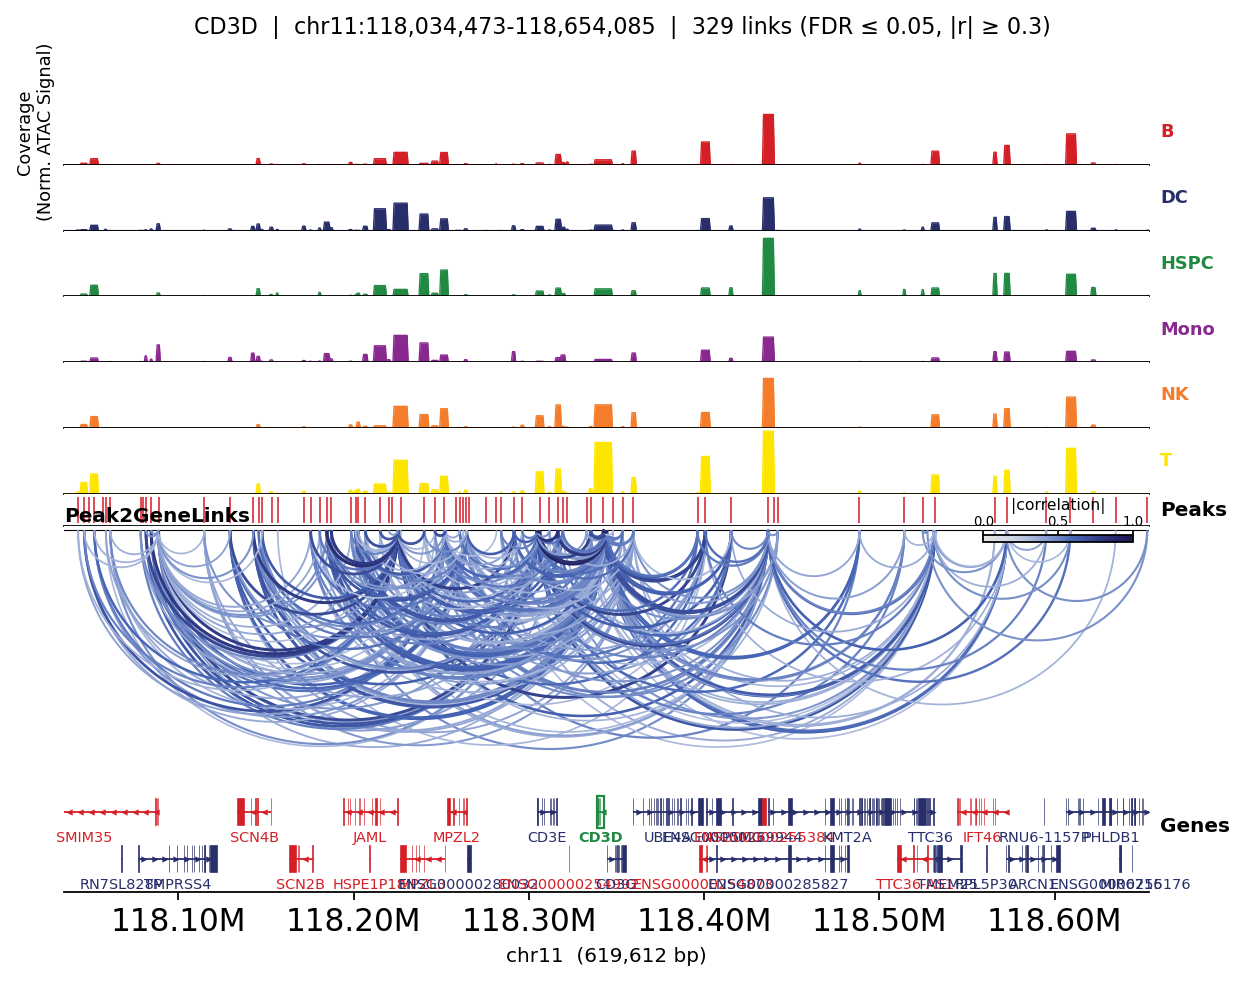

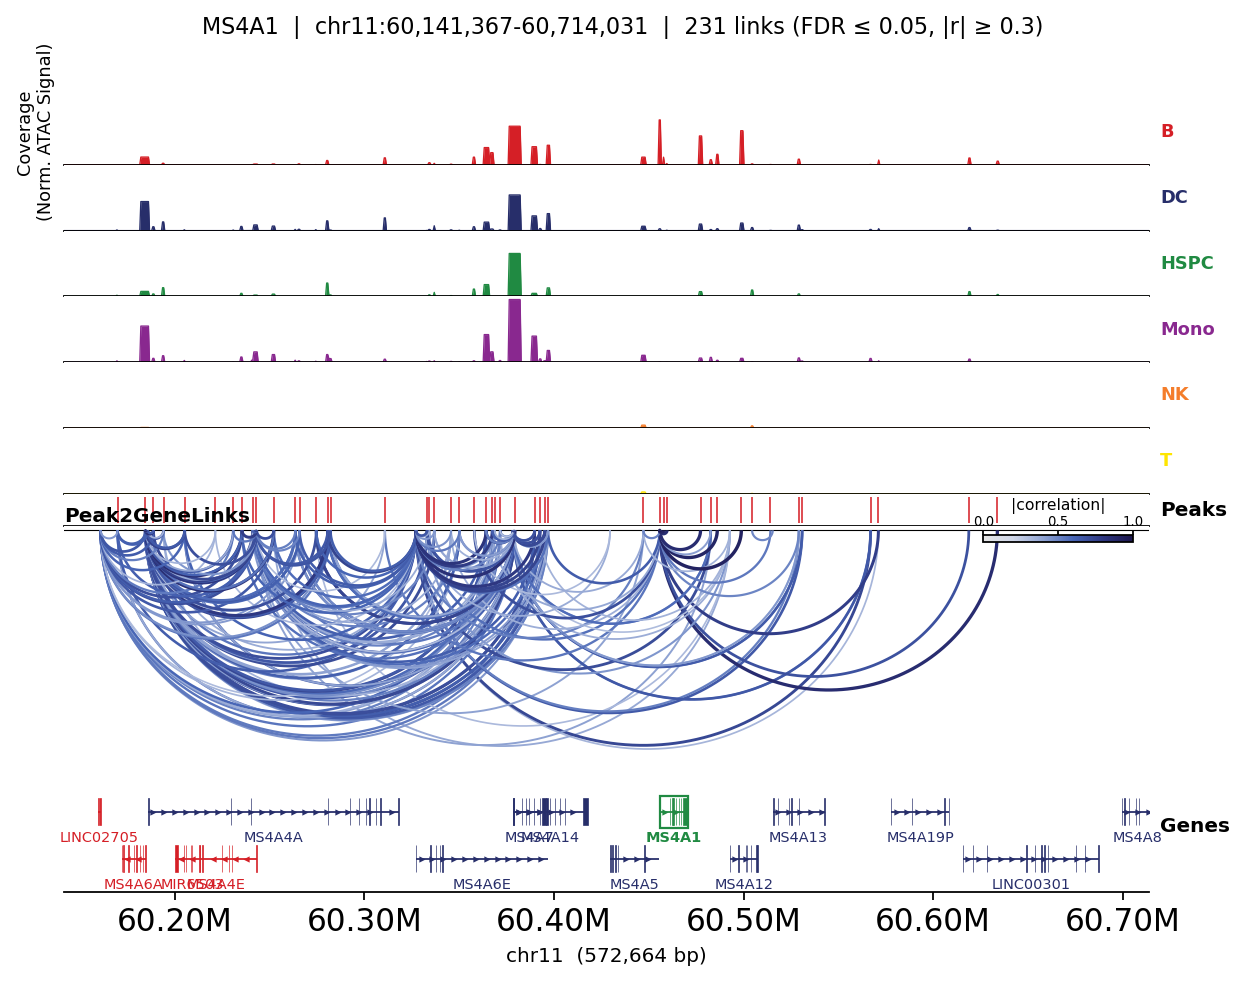

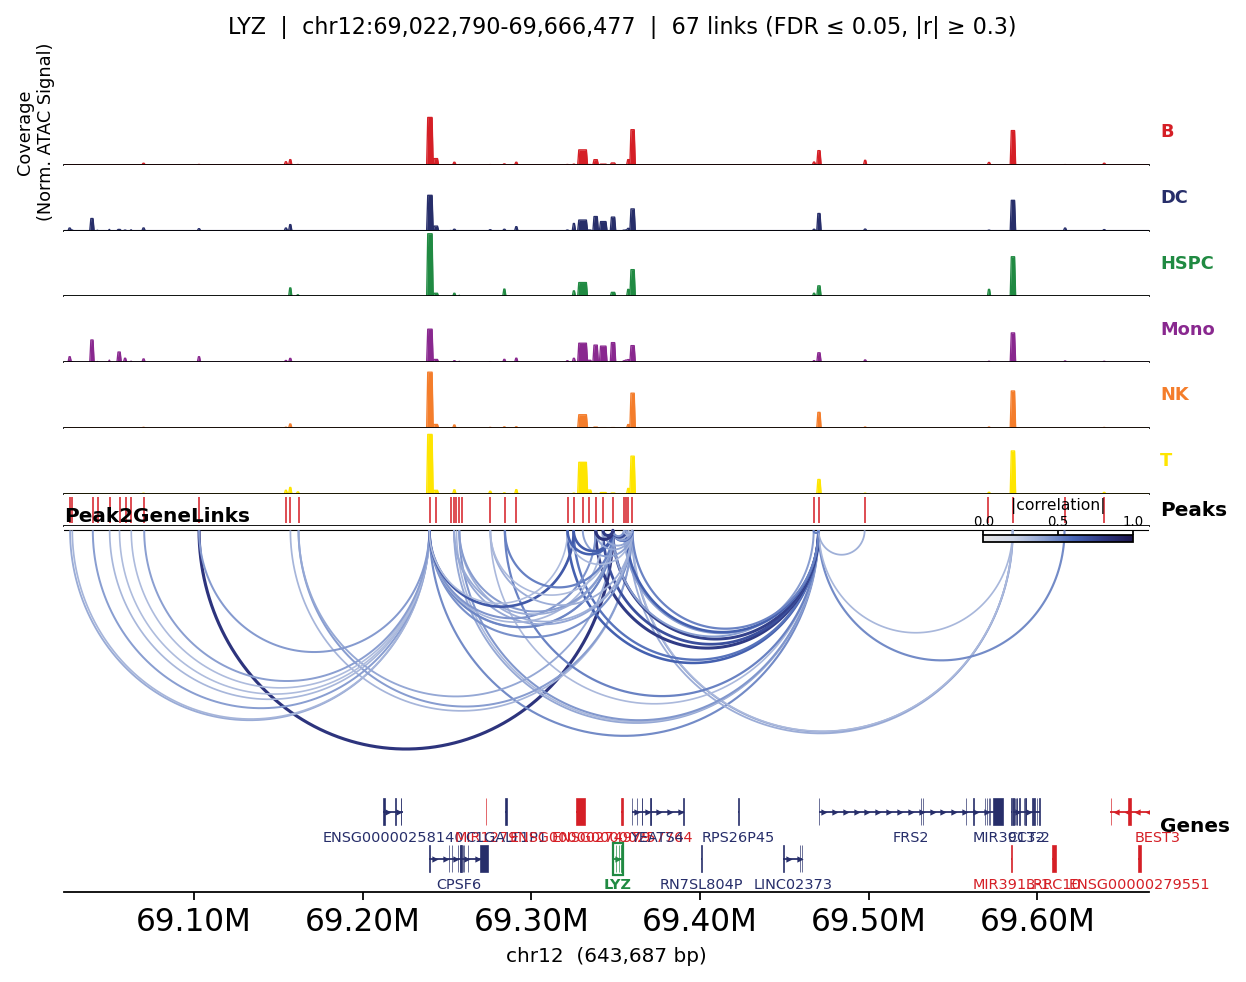

In [8]:
major = {
    'CD4 Naive':'T','CD4 TCM':'T','CD4 TEM':'T','Treg':'T','CD8 Naive':'T',
    'CD8 TEM_1':'T','CD8 TEM_2':'T','MAIT':'T','gdT':'T',
    'Naive B':'B','Memory B':'B','Intermediate B':'B','Plasma':'B',
    'NK':'NK','CD14 Mono':'Mono','CD16 Mono':'Mono','cDC':'DC','pDC':'DC','HSPC':'HSPC',
}
atac.obs['lineage'] = atac.obs['cell_type'].map(major).fillna('other').astype('category')

for gene in ['CD3D', 'MS4A1', 'LYZ']:
    fig, _ = ov.epi.pl.plot_peak2gene(
        atac, gene=gene, group_by='lineage',
        gene_annotation=gene_ann, exon_annotation=exon_ann,
        fdr_thresh=0.05, min_abs_r=0.3, pad_bp=80_000, figsize=(8, 4), show=False,
    )
    plt.tight_layout(); plt.show()

## Summary

| stage | function |
|---|---|
| load paired RNA+ATAC | `ov.epi.datasets.pbmc10k_multiome` |
| ATAC embedding | `ov.epi.tl.iterative_lsi` |
| peak↔gene correlation | `ov.epi.tl.peak_to_gene` |
| linkage plot | `ov.epi.pl.plot_peak2gene` |

Peak-to-gene links turn an anonymous accessibility peak into a candidate regulatory element for a
named gene — the foundation for enhancer-driven gene-regulatory analysis.